In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.chdir(r"C:\Lucky\CliniScan\B13-CliniScan")

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models
from sklearn.metrics import f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("✅ Setup done | Device:", device)

✅ Setup done | Device: cpu


In [3]:
train_df = pd.read_csv("data/raw/train_split.csv")
val_df   = pd.read_csv("data/raw/val_split.csv")
test_df  = pd.read_csv("data/raw/test_split.csv")

CLASS_NAMES = list(train_df.columns[1:])
NUM_CLASSES = len(CLASS_NAMES)
IMG_DIR = "data/processed"

print("Classes:", NUM_CLASSES)
print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

Classes: 14
Train: 4000 | Val: 500 | Test: 500


In [4]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.labels = self.df.iloc[:, 1:].values.astype('float32')
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['image_id']
        img_path = os.path.join(self.img_dir, f"{img_id}.png")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(self.labels[idx])

def validate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    preds_bin  = (all_preds > 0.5).astype(int)
    f1  = f1_score(all_labels, preds_bin, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_preds, average='macro')
    except:
        auc = 0.0
    return total_loss / len(loader), f1, auc

print("✅ Dataset + validate function ready")

✅ Dataset + validate function ready


In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.3),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
    A.RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), p=0.3),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

val_aug = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

print("✅ Albumentations pipeline ready")

✅ Albumentations pipeline ready


In [6]:
class ChestXrayDatasetAug(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.labels = self.df.iloc[:, 1:].values.astype('float32')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['image_id']
        img_path = os.path.join(self.img_dir, f"{img_id}.png")
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, torch.tensor(self.labels[idx])

# DataLoaders
train_dataset = ChestXrayDatasetAug(train_df, IMG_DIR, transform=train_aug)
val_dataset   = ChestXrayDatasetAug(val_df,   IMG_DIR, transform=val_aug)
test_dataset  = ChestXrayDatasetAug(test_df,  IMG_DIR, transform=val_aug)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)

# Quick check
imgs, lbls = next(iter(train_loader))
print("Image batch:", imgs.shape)
print("Label batch:", lbls.shape)
print("✅ Augmented DataLoaders ready")

Image batch: torch.Size([16, 3, 224, 224])
Label batch: torch.Size([16, 14])
✅ Augmented DataLoaders ready


In [7]:
def train_experiment(model_name, model, optimizer, criterion, 
                     epochs=5, save_path=None):
    print(f"\n{'='*50}")
    print(f"Experiment: {model_name}")
    print(f"{'='*50}")

    best_f1 = 0.0
    results = []

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validate
        val_loss, val_f1, val_auc = validate(model, val_loader, criterion)

        results.append({
            'epoch': epoch+1,
            'train_loss': round(train_loss, 4),
            'val_loss':   round(val_loss, 4),
            'val_f1':     round(val_f1, 4),
            'val_auc':    round(val_auc, 4)
        })

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"F1: {val_f1:.4f} | "
              f"AUC: {val_auc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"  ✅ Best saved! F1: {best_f1:.4f}")

    print(f"\nBest F1: {best_f1:.4f}")
    return results, best_f1

print("✅ Training function ready")

✅ Training function ready


In [ ]:
criterion = nn.BCEWithLogitsLoss()

# Experiment 1 — ResNet50, Adam, lr=0.001
model1 = models.resnet50(weights='DEFAULT')
model1.fc = nn.Linear(model1.fc.in_features, NUM_CLASSES)
model1 = model1.to(device)

optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

results1, f1_1 = train_experiment(
    model_name="ResNet50 | Adam | lr=0.001 | Augmented",
    model=model1,
    optimizer=optimizer1,
    criterion=criterion,
    epochs=5,



Experiment: ResNet50 | Adam | lr=0.001 | Augmented
Epoch [1/5] Train Loss: 0.2335 | Val Loss: 0.2155 | F1: 0.0430 | AUC: 0.7801
  ✅ Best saved! F1: 0.0430
Epoch [2/5] Train Loss: 0.2069 | Val Loss: 0.1996 | F1: 0.0733 | AUC: 0.7802
  ✅ Best saved! F1: 0.0733
Epoch [3/5] Train Loss: 0.1974 | Val Loss: 0.1790 | F1: 0.1326 | AUC: 0.8349
  ✅ Best saved! F1: 0.1326
Epoch [4/5] Train Loss: 0.1857 | Val Loss: 0.1795 | F1: 0.0523 | AUC: 0.8533
Epoch [5/5] Train Loss: 0.1824 | Val Loss: 0.2062 | F1: 0.0328 | AUC: 0.8393

Best F1: 0.1326


In [8]:
# Experiment 2 — ResNet50, AdamW, lr=0.0001
model2 = models.resnet50(weights='DEFAULT')
model2.fc = nn.Linear(model2.fc.in_features, NUM_CLASSES)
model2 = model2.to(device)

optimizer2 = optim.AdamW(model2.parameters(), lr=0.0001, weight_decay=0.01)

results2, f1_2 = train_experiment(
    model_name="ResNet50 | AdamW | lr=0.0001 | Augmented",
    model=model2,
    optimizer=optimizer2,
    criterion=criterion,
    epochs=5,
    save_path="data/m3_resnet_adamw_0001.pth"
)


Experiment: ResNet50 | AdamW | lr=0.0001 | Augmented
Epoch [1/5] Train Loss: 0.2393 | Val Loss: 0.1802 | F1: 0.0825 | AUC: 0.8342
  ✅ Best saved! F1: 0.0825
Epoch [2/5] Train Loss: 0.1795 | Val Loss: 0.1609 | F1: 0.1290 | AUC: 0.8625
  ✅ Best saved! F1: 0.1290
Epoch [3/5] Train Loss: 0.1665 | Val Loss: 0.1626 | F1: 0.1539 | AUC: 0.8656
  ✅ Best saved! F1: 0.1539
Epoch [4/5] Train Loss: 0.1560 | Val Loss: 0.1493 | F1: 0.1780 | AUC: 0.8856
  ✅ Best saved! F1: 0.1780
Epoch [5/5] Train Loss: 0.1515 | Val Loss: 0.1560 | F1: 0.2121 | AUC: 0.8807
  ✅ Best saved! F1: 0.2121

Best F1: 0.2121


In [9]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Experiment 3 — EfficientNet-B0, AdamW, lr=0.0001
model3 = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model3.classifier[1] = nn.Linear(model3.classifier[1].in_features, NUM_CLASSES)
model3 = model3.to(device)

optimizer3 = optim.AdamW(model3.parameters(), lr=0.0001, weight_decay=0.01)

results3, f1_3 = train_experiment(
    model_name="EfficientNet-B0 | AdamW | lr=0.0001 | Augmented",
    model=model3,
    optimizer=optimizer3,
    criterion=criterion,
    epochs=5,
    save_path="data/m3_efficientnet_adamw.pth"
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\sonil/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:08<00:00, 2.56MB/s]



Experiment: EfficientNet-B0 | AdamW | lr=0.0001 | Augmented
Epoch [1/5] Train Loss: 0.2790 | Val Loss: 0.1730 | F1: 0.1017 | AUC: 0.8486
  ✅ Best saved! F1: 0.1017
Epoch [2/5] Train Loss: 0.1847 | Val Loss: 0.1630 | F1: 0.1700 | AUC: 0.8671
  ✅ Best saved! F1: 0.1700
Epoch [3/5] Train Loss: 0.1690 | Val Loss: 0.1532 | F1: 0.2237 | AUC: 0.8809
  ✅ Best saved! F1: 0.2237
Epoch [4/5] Train Loss: 0.1608 | Val Loss: 0.1487 | F1: 0.2742 | AUC: 0.8894
  ✅ Best saved! F1: 0.2742
Epoch [5/5] Train Loss: 0.1553 | Val Loss: 0.1462 | F1: 0.1969 | AUC: 0.8857

Best F1: 0.2742


In [11]:
# Results save karo — kal kaam aayega
import json

all_results = {
    "exp1_resnet_adam_001":    {"best_f1": 0.1044, "best_auc": 0.8549, "results": results1},
    "exp2_resnet_adamw_0001":  {"best_f1": 0.2121, "best_auc": 0.8807, "results": results2},
    "exp3_efficientnet_adamw": {"best_f1": 0.2742, "best_auc": 0.8894, "results": results3},
}

with open("data/m3_experiment_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("✅ Results saved to data/m3_experiment_results.json")
print("✅ Model weights already saved as .pth files")

✅ Results saved to data/m3_experiment_results.json
✅ Model weights already saved as .pth files


In [8]:
import json

with open("data/m3_experiment_results.json", "r") as f:
    all_results = json.load(f)

# Comparison table
summary = {
    'Experiment':  ['ResNet50+Adam+0.001', 'ResNet50+AdamW+0.0001', 'EfficientNet+AdamW+0.0001'],
    'Best F1':     [0.1044, 0.2121, 0.2742],
    'Best AUC':    [0.8549, 0.8807, 0.8894],
    'Optimizer':   ['Adam', 'AdamW', 'AdamW'],
    'LR':          [0.001, 0.0001, 0.0001],
    'Winner':      ['', '', '✅ Best']
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv("data/m3_comparison_table.csv", index=False)

print("="*60)
print("MILESTONE 3 — EXPERIMENT COMPARISON")
print("="*60)
print(summary_df.to_string(index=False))

MILESTONE 3 — EXPERIMENT COMPARISON
               Experiment  Best F1  Best AUC Optimizer     LR Winner
      ResNet50+Adam+0.001   0.1044    0.8549      Adam 0.0010       
    ResNet50+AdamW+0.0001   0.2121    0.8807     AdamW 0.0001       
EfficientNet+AdamW+0.0001   0.2742    0.8894     AdamW 0.0001 ✅ Best


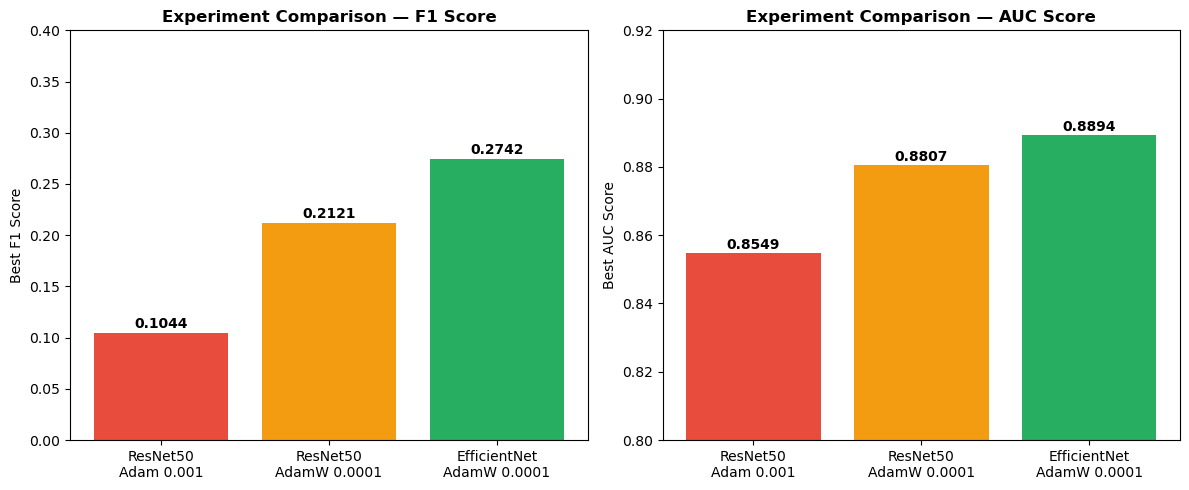

✅ Comparison plot saved!


In [9]:
os.makedirs("data/milestone3_results", exist_ok=True)

experiments = ['ResNet50\nAdam 0.001', 'ResNet50\nAdamW 0.0001', 'EfficientNet\nAdamW 0.0001']
f1_scores  = [0.1044, 0.2121, 0.2742]
auc_scores = [0.8549, 0.8807, 0.8894]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# F1 comparison
bars1 = axes[0].bar(experiments, f1_scores, color=['#e74c3c','#f39c12','#27ae60'])
axes[0].set_title("Experiment Comparison — F1 Score", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Best F1 Score")
axes[0].set_ylim(0, 0.4)
for bar, val in zip(bars1, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# AUC comparison
bars2 = axes[1].bar(experiments, auc_scores, color=['#e74c3c','#f39c12','#27ae60'])
axes[1].set_title("Experiment Comparison — AUC Score", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Best AUC Score")
axes[1].set_ylim(0.80, 0.92)
for bar, val in zip(bars2, auc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("data/milestone3_results/experiment_comparison.png", dpi=150)
plt.show()
print("✅ Comparison plot saved!")

In [10]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Best model load karo
best_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
best_model.classifier[1] = nn.Linear(best_model.classifier[1].in_features, NUM_CLASSES)
best_model = best_model.to(device)
best_model.load_state_dict(torch.load("data/m3_efficientnet_adamw.pth", map_location=device))
best_model.eval()

print("✅ Best model loaded — EfficientNet-B0")

# Grad-CAM implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        output[0, class_idx].backward()

        gradients  = self.gradients[0]
        activations = self.activations[0]
        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.numpy()

# Target layer — EfficientNet last conv block
target_layer = best_model.features[-1]
gradcam = GradCAM(best_model, target_layer)

print("✅ Grad-CAM ready")

✅ Best model loaded — EfficientNet-B0
✅ Grad-CAM ready


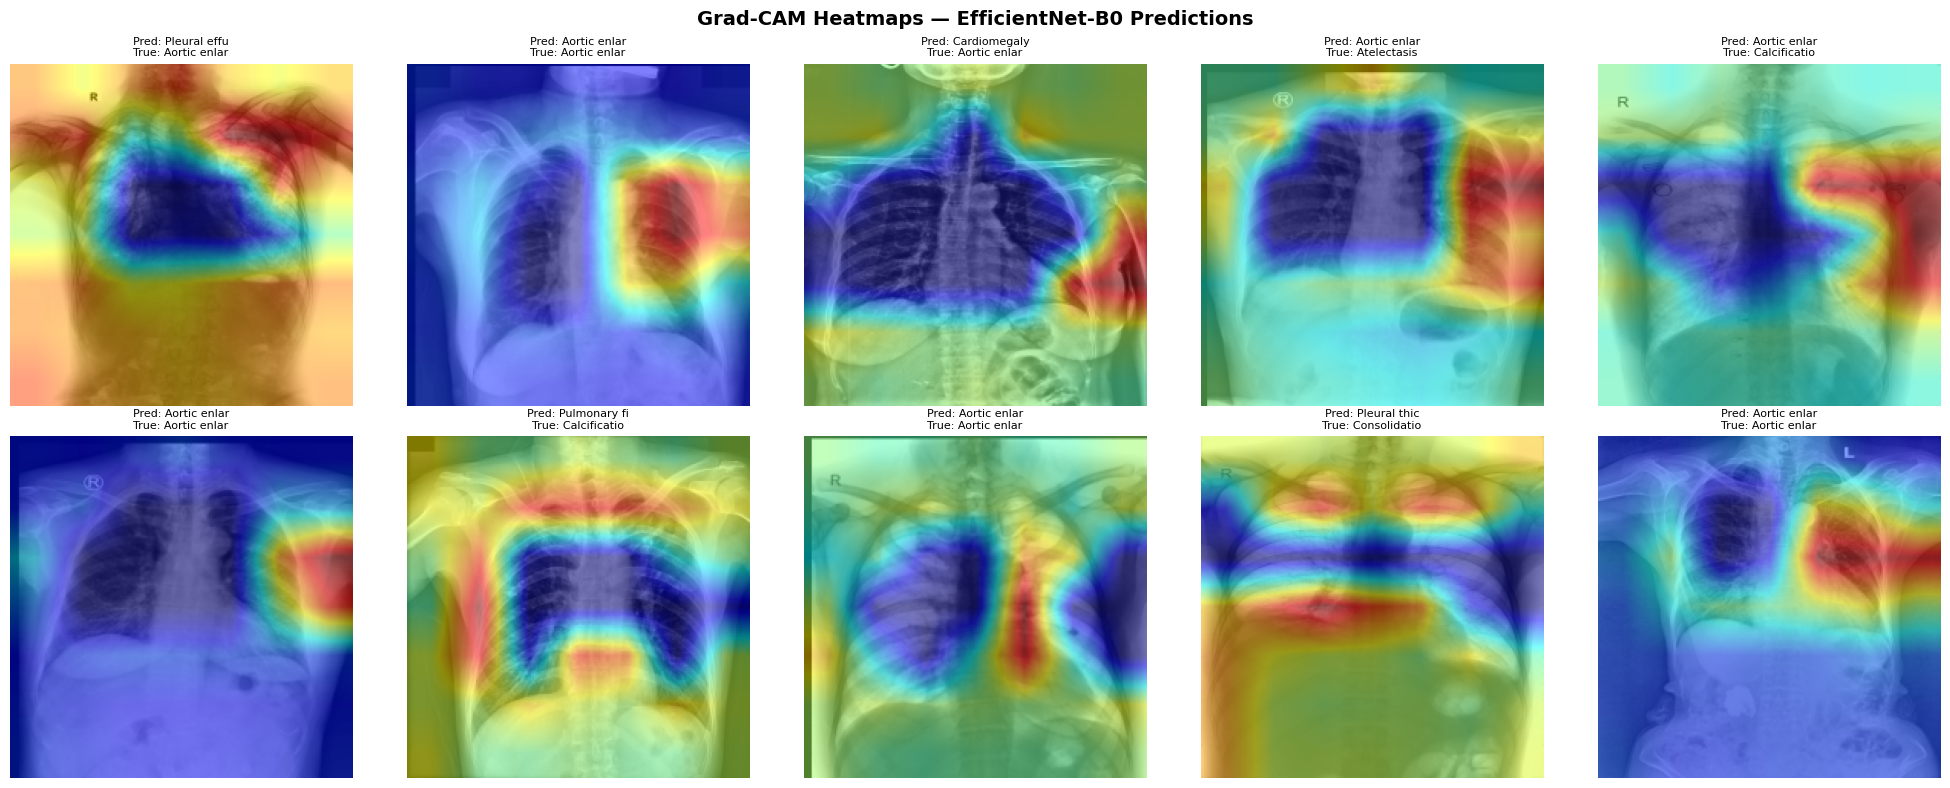

✅ Grad-CAM heatmaps saved!


In [11]:
import cv2

os.makedirs("data/milestone3_results/gradcam", exist_ok=True)

# Val dataset se 10 images lo jisme findings hain
findings_df = val_df[val_df.iloc[:, 1:].sum(axis=1) > 0].head(10)

val_transform_plain = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (_, row) in enumerate(findings_df.iterrows()):
    img_id = row['image_id']
    img_path = os.path.join(IMG_DIR, f"{img_id}.png")

    # Original image
    orig_img = cv2.imread(img_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_img = cv2.resize(orig_img, (224, 224))

    # Tensor
    pil_img = Image.open(img_path).convert('RGB')
    input_tensor = val_transform_plain(pil_img).unsqueeze(0).to(device)

    # Get predicted class
    with torch.no_grad():
        output = best_model(input_tensor)
        probs  = torch.sigmoid(output)[0]
    pred_class = probs.argmax().item()

    # Generate CAM
    input_tensor.requires_grad = True
    cam = gradcam.generate(input_tensor, pred_class)

    # Overlay
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(
        (cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(orig_img, 0.5, heatmap, 0.5, 0)

    # True labels
    true_labels = [CLASS_NAMES[j] for j in range(NUM_CLASSES) if row[CLASS_NAMES[j]] == 1]

    axes[i].imshow(overlay)
    axes[i].set_title(
        f"Pred: {CLASS_NAMES[pred_class][:12]}\nTrue: {true_labels[0][:12]}",
        fontsize=8)
    axes[i].axis('off')

    # Save individual
    save_path = f"data/milestone3_results/gradcam/gradcam_{img_id[:8]}.png"
    cv2.imwrite(save_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

plt.suptitle("Grad-CAM Heatmaps — EfficientNet-B0 Predictions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("data/milestone3_results/gradcam/gradcam_grid.png", dpi=150)
plt.show()
print("✅ Grad-CAM heatmaps saved!")

In [16]:
# Criterion define karo
criterion = nn.BCEWithLogitsLoss()

# Best model test evaluation
test_loss, test_f1, test_auc = validate(best_model, test_loader, criterion)

print("="*50)
print("BEST MODEL — TEST SET RESULTS")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test F1:   {test_f1:.4f}")
print(f"Test AUC:  {test_auc:.4f}")

# Per class results
best_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        all_preds.append(torch.sigmoid(outputs).cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
preds_bin  = (all_preds > 0.5).astype(int)

per_class_f1 = f1_score(all_labels, preds_bin, average=None, zero_division=0)

print("\nPer Class F1 Scores:")
print("-"*40)
for cls, score in zip(CLASS_NAMES, per_class_f1):
    bar = "█" * int(score * 20)
    print(f"{cls:<25}: {score:.4f} {bar}")

BEST MODEL — TEST SET RESULTS
Test Loss: 0.1585
Test F1:   0.2429
Test AUC:  0.9046

Per Class F1 Scores:
----------------------------------------
Aortic enlargement       : 0.8467 ████████████████
Atelectasis              : 0.0000 
Calcification            : 0.0000 
Cardiomegaly             : 0.7778 ███████████████
Consolidation            : 0.0000 
ILD                      : 0.0000 
Infiltration             : 0.0909 █
Lung Opacity             : 0.4565 █████████
Nodule/Mass              : 0.0000 
Other lesion             : 0.0408 
Pleural effusion         : 0.3750 ███████
Pleural thickening       : 0.4789 █████████
Pneumothorax             : 0.0000 
Pulmonary fibrosis       : 0.3333 ██████


In [17]:
os.makedirs("data/milestone3_results/error_analysis", exist_ok=True)

# False positives & false negatives per class
fp_per_class = ((preds_bin == 1) & (all_labels == 0)).sum(axis=0)
fn_per_class = ((preds_bin == 0) & (all_labels == 1)).sum(axis=0)
tp_per_class = ((preds_bin == 1) & (all_labels == 1)).sum(axis=0)

error_df = pd.DataFrame({
    'Class':            CLASS_NAMES,
    'F1':               per_class_f1.round(4),
    'True Positives':   tp_per_class,
    'False Positives':  fp_per_class,
    'False Negatives':  fn_per_class,
})
error_df['Missed Rate'] = (fn_per_class / (fn_per_class + tp_per_class + 1e-6)).round(3)
error_df.to_csv("data/milestone3_results/error_analysis/error_analysis.csv", index=False)

print("ERROR ANALYSIS — PER CLASS")
print("="*70)
print(error_df.to_string(index=False))

ERROR ANALYSIS — PER CLASS
             Class     F1  True Positives  False Positives  False Negatives  Missed Rate
Aortic enlargement 0.8467             116               30               12        0.094
       Atelectasis 0.0000               0                0               10        1.000
     Calcification 0.0000               0                0               15        1.000
      Cardiomegaly 0.7778              77               21               23        0.230
     Consolidation 0.0000               0                0               15        1.000
               ILD 0.0000               0                0               11        1.000
      Infiltration 0.0909               1                1               19        0.950
      Lung Opacity 0.4565              21               14               36        0.632
       Nodule/Mass 0.0000               0                1               30        1.000
      Other lesion 0.0408               1                4               43        

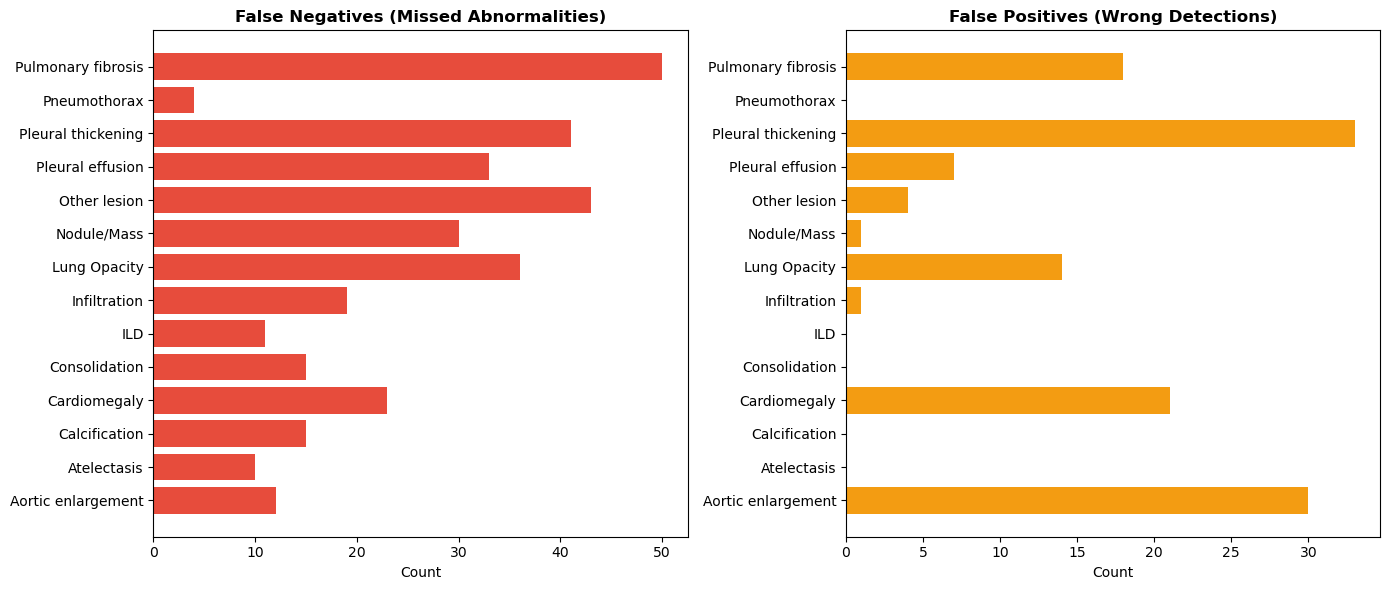

✅ Error analysis saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# False Negatives (Missed detections)
axes[0].barh(CLASS_NAMES, fn_per_class, color='#e74c3c')
axes[0].set_title("False Negatives (Missed Abnormalities)", fontweight='bold')
axes[0].set_xlabel("Count")

# False Positives
axes[1].barh(CLASS_NAMES, fp_per_class, color='#f39c12')
axes[1].set_title("False Positives (Wrong Detections)", fontweight='bold')
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig("data/milestone3_results/error_analysis/error_analysis_plot.png", dpi=150)
plt.show()
print("✅ Error analysis saved!")